In [ ]:
pip install -q torchvision

In [ ]:
import kagglehub
import os
import random
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

100%|██████████| 2.70G/2.70G [00:35<00:00, 81.5MB/s]

Extracting files...


Apple___Black_rot
256
256


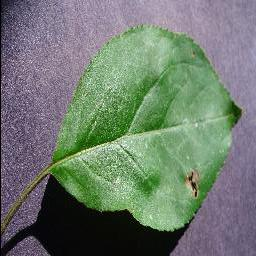

In [ ]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
class_name = random.choice(classes)
class_path = os.path.join(train_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(class_name)
print(img.width)
print(img.height)
img

In [ ]:
import torch
import torch.nn as nn

In [ ]:
s = torch.tensor(10)
s
s.ndim

0

In [ ]:
v = torch.tensor([10,10])
v.ndim

1

In [ ]:
m = torch.tensor([[1,2,3],
                  [4,5,6],
                  [7,8,9]])
m.shape

torch.Size([3, 3])

In [ ]:
t = torch.tensor([[[1,2,3],
                  [4,5,6],
                  [7,8,9]]])
t.shape

torch.Size([1, 3, 3])

In [ ]:
s = s.squeeze(dim=0)
s

tensor(10)

In [ ]:
torch.manual_seed(42)
a = torch.rand(3, 3)
a
# a.shape
# a.device
a.dtype


torch.float32

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
weight, bias = 0.7, 0.3

In [ ]:
X = torch.arange(0, 2, 0.02).unsqueeze(dim=1)
y = weight * X + bias
len(X), len(y)

(100, 100)

In [ ]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [ ]:
class SampleModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
  def forward(self, x: torch.Tensor):
    return (self.weight * x) + self.bias


In [ ]:
torch.manual_seed(42)
model_first = SampleModel()

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_first.parameters(), lr=0.00001)

In [ ]:
def plot_predictions(X_train, y_train, X_test, y_test, y_preds=None):
  plt.scatter(X_train, y_train, c ="b")
  plt.scatter(X_test, y_test, c = "g")
  if y_preds is not None:
    plt.scatter(X_test, y_preds, c="r")

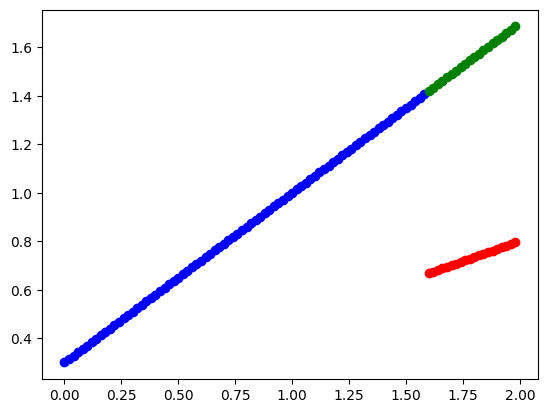

In [ ]:


with torch.inference_mode():
    y_preds = model_first(X_test)

plot_predictions(X_train, y_train, X_test, y_test, y_preds)


In [ ]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_first.train()

  y_pred = model_first(X_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_first.eval()
  with torch.inference_mode():
    test_pred = model_first(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"epoch {epoch} | loss {loss} | test loss {test_loss}")

epoch 0 | loss 0.4582051634788513 | test loss 0.8214906454086304
epoch 10 | loss 0.45804286003112793 | test loss 0.8212493062019348
epoch 20 | loss 0.457880437374115 | test loss 0.821008026599884
epoch 30 | loss 0.4577180743217468 | test loss 0.8207665681838989
epoch 40 | loss 0.4575556814670563 | test loss 0.8205251693725586
epoch 50 | loss 0.4573933184146881 | test loss 0.8202838897705078
epoch 60 | loss 0.45723095536231995 | test loss 0.820042610168457
epoch 70 | loss 0.4570685923099518 | test loss 0.8198012113571167
epoch 80 | loss 0.45690616965293884 | test loss 0.8195598721504211
epoch 90 | loss 0.4567438066005707 | test loss 0.8193184733390808


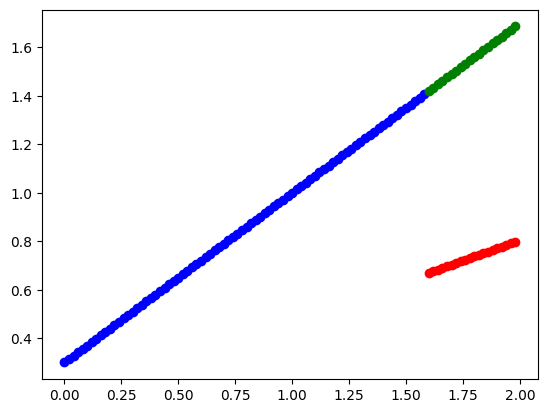

In [ ]:
with torch.inference_mode():
  y_preds = model_first(X_test)
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [ ]:
model_first.state_dict()


OrderedDict([('weight', tensor([0.3375])), ('bias', tensor([0.1298]))])

In [ ]:
len(classes)

38

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from PIL import Image

In [ ]:
data_transformers = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform = None)

In [ ]:
valid_dataset = datasets.ImageFolder(root = val_path, transform = None)

In [ ]:
len(train_dataset), len(valid_dataset)

(70295, 17572)

In [ ]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # resize all images to 224x224
    transforms.RandomHorizontalFlip(),   # randomly flip images
    transforms.RandomRotation(20),       # rotate a bit
    transforms.ToTensor(),               # convert to tensor
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])  # normalize
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
transformed_image = data_transformers(img)
print(transformed_image)

tensor([[[0.0000, 0.1098, 0.0863,  ..., 0.5608, 0.5686, 0.5647],
         [0.0000, 0.1137, 0.1255,  ..., 0.5451, 0.5529, 0.5451],
         [0.0000, 0.0745, 0.0941,  ..., 0.5412, 0.5451, 0.5333],
         ...,
         [0.0196, 0.0392, 0.0510,  ..., 0.4235, 0.4157, 0.4157],
         [0.0039, 0.0784, 0.0392,  ..., 0.3922, 0.3843, 0.3882],
         [0.0039, 0.1216, 0.0471,  ..., 0.3725, 0.3686, 0.3804]],

        [[0.0000, 0.1020, 0.0784,  ..., 0.5294, 0.5373, 0.5333],
         [0.0000, 0.1059, 0.1176,  ..., 0.5137, 0.5216, 0.5137],
         [0.0000, 0.0667, 0.0863,  ..., 0.5098, 0.5137, 0.5020],
         ...,
         [0.0078, 0.0275, 0.0314,  ..., 0.3843, 0.3765, 0.3765],
         [0.0000, 0.0667, 0.0196,  ..., 0.3529, 0.3451, 0.3490],
         [0.0000, 0.1098, 0.0275,  ..., 0.3333, 0.3294, 0.3412]],

        [[0.0353, 0.1451, 0.1216,  ..., 0.6235, 0.6314, 0.6275],
         [0.0353, 0.1490, 0.1608,  ..., 0.6078, 0.6157, 0.6078],
         [0.0353, 0.1098, 0.1294,  ..., 0.6039, 0.6078, 0.

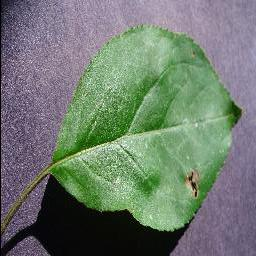

In [ ]:
img

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 2 )


In [ ]:
valid_loader = DataLoader(valid_dataset, batch_size = 32, shuffle =True, num_workers = 2 )

In [ ]:
len(train_loader), len(valid_loader)

(2197, 550)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
dummy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=dummy_transform)

In [ ]:
def compute_mean_std(dataset, batch_size=16, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, shuffle = False, num_workers=2)
  channel_sum = torch.zeros(3, device=device)
  channel_sqsum = torch.zeros(3, device=device)
  pixel_count = 0

  for x, _ in loader:
    x = x.to(device)
    b, c, h, w = x.shape
    pixel_count+= h * w * b
    channel_sum += x.sum(dim=[0, 2, 3])
    channel_sqsum += (x**2).sum(dim=[0, 2, 3])

  mean = channel_sum / pixel_count
  std = torch.sqrt(channel_sqsum/ pixel_count - mean ** 2)
  return  mean, std

In [ ]:
mean = [0.47596338391304016, 0.5003822445869446, 0.42664194107055664]
std = [0.21028108894824982, 0.18884526193141937, 0.22626696527004242]

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)

In [ ]:
test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle = False, num_workers=2)

In [ ]:
class SimpleCNN(nn.Module):
  def __init__(self, in_features, out_features, hidden_units):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=in_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=out_features)
    )

  def forward(self, x):
    return self.layer(x)

In [ ]:
model = SimpleCNN(3*224*224, 38, 256)
model.to(device)

SimpleCNN(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=38, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)
epochs = 5

for epoch in range(epochs):
  print(f"Epoch: {epoch+1}")
  print("----------------------")
  train_loss = 0
  test_loss = 0
  for X, y in train_loader:
    X, y = X.to(device), y.to(device)
    model.train()

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss+=loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
  train_loss /= len(train_loader)
  model.eval()
  with torch.inference_mode():
    for X_test, y_test in test_loader:
      X_test, y_test = X_test.to(device), y_test.to(device)
      y_test_pred = model(X_test)
      test_loss+= loss_fn(y_test_pred, y_test).item()
    test_loss /= len(test_loader)



  print(f"train loss: {train_loss} | test loss: {test_loss}")


Epoch: 1
----------------------
train loss: nan | test loss: nan
Epoch: 2
----------------------
train loss: nan | test loss: nan
Epoch: 3
----------------------
train loss: nan | test loss: nan
Epoch: 4
----------------------
train loss: nan | test loss: nan
Epoch: 5
----------------------
train loss: nan | test loss: nan


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*28*28, 256),  # Make sure input images are 224x224
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=38).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)